In [20]:
import pandas as pd
import os
import sys
import seaborn as sns
sys.path.insert(0, '..')
from src.sampling import create_stratified_sample
from src.chunking import (
    create_documents,
    chunk_documents
)

In [21]:
df = pd.read_csv(
    "../data/processed/filtered_complaints.csv"
)

print(df.shape)

(445456, 21)


In [22]:
sample_df = create_stratified_sample(
    df,
    sample_size=12000
)

print(sample_df.shape)

sample_df["product_category"].value_counts()

(12000, 21)


product_category
Credit Card        5099
Savings Account    3779
Money Transfer     2658
Personal Loan       464
Name: count, dtype: int64

In [23]:
documents = create_documents(
    sample_df
)

print(
    f"Documents: {len(documents)}"
)

Documents: 12000


In [25]:
documents = create_documents(sample_df)
print(len(documents))
documents[0]

12000


Document(metadata={'complaint_id': '2362656', 'product_category': 'Credit Card'}, page_content="a couple of years ago, i made a purchase on a target credit card at target. 35.00 . i then went o until . i found the 35.00 in the mail upon return, now being charged 100 in late fees. i paid it in full after getting one month payment voided, then tore up the card and forgot about it. recently i learned that this is the only delinquency on my credit report, and that the amount is not specified, classified as a serious '' delinquency, and tells me it will be on my report for 10 years! nothing they can do, nothing target can do, so they say. can you change this? can you get effect a rule change whereby delinquencies below a certain amount are treated less severely, like under 100.00 , must come off the credit report once paid, and maybe a sliding scale based on the amount and time of debt owed, like -2 years, , 5 years, etc. please respond,")

In [26]:
chunks = chunk_documents(
    documents
)

print(
    f"Total Chunks: {len(chunks)}"
)

Total Chunks: 34079


In [27]:
chunks[0]

Document(metadata={'complaint_id': '2362656', 'product_category': 'Credit Card'}, page_content="a couple of years ago, i made a purchase on a target credit card at target. 35.00 . i then went o until . i found the 35.00 in the mail upon return, now being charged 100 in late fees. i paid it in full after getting one month payment voided, then tore up the card and forgot about it. recently i learned that this is the only delinquency on my credit report, and that the amount is not specified, classified as a serious '' delinquency, and tells me it will be on my report for 10 years! nothing")

In [28]:
chunks[0].metadata

{'complaint_id': '2362656', 'product_category': 'Credit Card'}

In [29]:
print(
    f"Documents: {len(documents)}"
)

print(
    f"Chunks: {len(chunks)}"
)

print(
    f"Average Chunks Per Complaint: "
    f"{len(chunks)/len(documents):.2f}"
)

Documents: 12000
Chunks: 34079
Average Chunks Per Complaint: 2.84


In [30]:
chunk_lengths = [
    len(chunk.page_content)
    for chunk in chunks
]

pd.Series(
    chunk_lengths
).describe()

count    34079.000000
mean       414.135538
std        133.947308
min         23.000000
25%        345.000000
50%        495.000000
75%        498.000000
max        500.000000
dtype: float64

In [31]:
chunks = chunk_documents(documents)

print("Documents:", len(documents))
print("Chunks:", len(chunks))
print(
    "Average Chunks Per Complaint:",
    len(chunks)/len(documents)
)

chunks[0].metadata

Documents: 12000
Chunks: 34079
Average Chunks Per Complaint: 2.839916666666667


{'complaint_id': '2362656', 'product_category': 'Credit Card'}

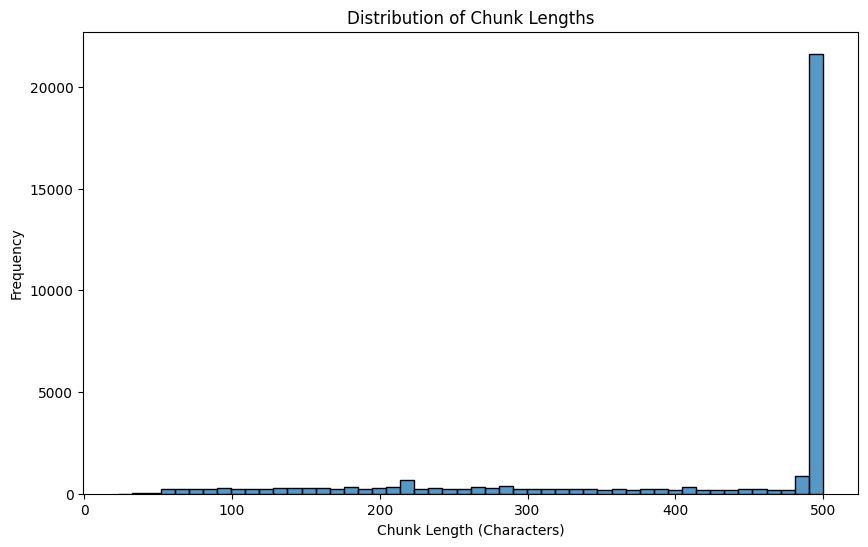

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.histplot(
    chunk_lengths,
    bins=50
)

plt.title("Distribution of Chunk Lengths")
plt.xlabel("Chunk Length (Characters)")
plt.ylabel("Frequency")

plt.show()

In [34]:
from langchain_huggingface import HuggingFaceEmbeddings

embedding_model = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

vector = embedding_model.embed_query(
    chunks[0].page_content
)

print(len(vector))

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4291.85it/s]


384


In [37]:
from importlib import reload
import src.vector_store

reload(src.vector_store)

from src.vector_store import get_embedding_model

In [38]:
from langchain_chroma import Chroma

from src.vector_store import (
    get_embedding_model
)

embedding_model = get_embedding_model()

db = Chroma(
    persist_directory="../vector_store",
    embedding_function=embedding_model
)

results = db.similarity_search(
    "unauthorized credit card charges",
    k=3
)

for i, doc in enumerate(results, start=1):

    print("=" * 60)
    print(f"Result {i}")
    print(doc.metadata)
    print(doc.page_content[:300])

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6058.92it/s]


Result 1
{'complaint_id': '3668834', 'product_category': 'Credit Card'}
walked from home to ; made purchase ; paid with credit card ; stopped by hand sanitizer after paying. lost credit card at some time after paying and before actually arriving back at my home. some hours later, i could not find the credit card ; searched premises ; checked online account transactions.
Result 2
{'complaint_id': '6162922', 'product_category': 'Credit Card'}
unauthorized charge on my card and care credit allowed the charge.
Result 3
{'complaint_id': '12510667', 'product_category': 'Savings Account'}
there were multiple times my card was charged days later for transactions already made.there were times there were unauthorized purchases i called to complain or ask and nothing was done.


In [40]:
results = db.similarity_search(
    "unauthorized credit card charges",
    k=3
)